
# Month 2 — Part 1: Multiple Linear Regression in Practice

This notebook is my own distilled learning artifact for:

- multiple linear regression
- vectorization
- gradient descent with multiple features
- feature scaling
- learning-rate / convergence diagnostics
- feature engineering
- polynomial regression
- the normal equation / least-squares solution

It is intentionally written from scratch rather than reproducing course solution notebooks.

The main transition from Month 1 is:

$$
\text{single feature} \quad wx+b
$$

                                                                
                                                                 to

$$
\text{multiple features} \quad \mathbf{w}^T\mathbf{x}+b.
$$



## 1. Multiple linear regression

For one training example with $n$ features,

$$
\mathbf{x}^{(i)}
=
\begin{bmatrix}
x_1^{(i)} \\
x_2^{(i)} \\
\vdots \\
x_n^{(i)}
\end{bmatrix},
\qquad
\mathbf{w}
=
\begin{bmatrix}
w_1 \\
w_2 \\
\vdots \\
w_n
\end{bmatrix}.
$$

The prediction becomes

$$
f_{\mathbf w,b}(\mathbf{x}^{(i)})
=
\mathbf{w}^T\mathbf{x}^{(i)}+b.
$$

For the whole dataset,

$$
X \in \mathbb{R}^{m\times n},
\qquad
\mathbf w \in \mathbb{R}^{n},
\qquad
\mathbf y \in \mathbb{R}^{m}.
$$

The important idea is that the underlying regression model has not fundamentally changed.  
The scalar feature and scalar weight have simply become vectors.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [2104., 5., 1., 45.],
    [1416., 3., 2., 40.],
    [1534., 3., 2., 30.],
    [852.,  2., 1., 36.],
])

y = np.array([460., 232., 315., 178.])

print("X shape:", X.shape) 
print("y shape:", y.shape)


X shape: (4, 4)
y shape: (4,)



## 2. Vectorization

A prediction can be written manually as

$$
w_1x_1+w_2x_2+\cdots+w_nx_n+b,
$$

but this is exactly a dot product:

$$
\mathbf w^T\mathbf x+b.
$$

Vectorization matters because it:

- makes the mathematical structure clearer,
- avoids explicit Python loops where possible,
- uses optimized numerical kernels,
- maps naturally to parallel numerical hardware.

This part was mainly recall for me; the new part is using the same representation inside multi-feature regression.


In [9]:
w_demo = np.array([0.20, 12.0, -8.0, -1.5])
b_demo = 25.0

x0 = X[0]

prediction_loop = 0
for i in range(len(w_demo)):
    prediction_loop += (w_demo[i] * x0[i])
prediction_loop += b_demo
prediction_dot = np.dot(x0, w_demo) + b_demo

print("Loop prediction:", prediction_loop)
print("Dot-product prediction:", prediction_dot)
print("Same result:", np.isclose(prediction_loop, prediction_dot))


Loop prediction: 430.3
Dot-product prediction: 430.3
Same result: True



## 3. Cost function with multiple features

The squared-error objective keeps the same form:

$$
J(\mathbf w,b)
=
\frac{1}{2m}
\sum_{i=1}^{m}
\left(
f_{\mathbf w,b}(\mathbf x^{(i)})-y^{(i)}
\right)^2.
$$

In vector notation:

$$
J(\mathbf w,b)
=
\frac{1}{2m}
\left\|
X\mathbf w+b\mathbf 1-\mathbf y
\right\|_2^2.
$$


In [10]:
def predict(X, w, b):
    return X @ w + b

def compute_cost(X, y, w, b):
    residuals = predict(X, w, b) - y
    return np.mean(residuals ** 2) / 2

w0 = np.zeros(X.shape[1])
b0 = 0.0

print("Initial cost:", compute_cost(X, y, w0, b0))


Initial cost: 49541.625



## 4. Gradient: scalar $\rightarrow$ vector

For each feature $j$,

$$
\frac{\partial J}{\partial w_j}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(
f_{\mathbf w,b}(\mathbf x^{(i)})-y^{(i)}
\right)x_j^{(i)}.
$$

The bias derivative is

$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(
f_{\mathbf w,b}(\mathbf x^{(i)})-y^{(i)}
\right).
$$

All weight derivatives can be written together:

$$
\nabla_{\mathbf w}J
=
\frac{1}{m}
X^T
\left(
X\mathbf w+b-\mathbf y
\right).
$$

This is the multi-feature equivalent of the single-feature gradient I wrote myself in the practice lab.


In [11]:
def compute_gradient(X, y, w, b):
    m = X.shape[0]
    residuals = predict(X, w, b) - y

    dj_dw = (X.T @ residuals) / m
    dj_db = np.mean(residuals)

    return dj_dw, dj_db

dj_dw, dj_db = compute_gradient(X, y, w0, b0)

print("dJ/dw:", dj_dw)
print("dJ/db:", dj_db)


dJ/dw: [-4.828045e+05 -1.074250e+03 -4.330000e+02 -1.145950e+04]
dJ/db: -296.25



### Recall from my own single-feature implementation

In the single-feature case I had already implemented the same idea explicitly:

```python
for i in range(m):
    y_hat = w * x[i] + b
    total_cost += (y_hat - y[i]) ** 2
```

and the gradients were accumulated sample by sample.

The new conceptual step is not a new optimization algorithm. It is recognizing that the same calculation becomes a matrix/vector operation when there are multiple features.



## 5. Batch gradient descent

The update is now

$$
\mathbf w
\leftarrow
\mathbf w-\alpha\nabla_{\mathbf w}J
$$

and

$$
b
\leftarrow
b-\alpha\frac{\partial J}{\partial b}.
$$

The updates should be computed from the same old parameter state.

This is still **batch gradient descent** because every update uses the whole training set.


In [12]:
def gradient_descent(X, y, w_init=None, b_init=0.0, alpha=0.01, num_iters=1000):
    n = X.shape[1]

    w = np.zeros(n) if w_init is None else np.array(w_init, dtype=float).copy()
    b = float(b_init)

    history = []

    for _ in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)

        new_w = w - alpha * dj_dw
        new_b = b - alpha * dj_db

        w, b = new_w, new_b
        history.append(compute_cost(X, y, w, b))

    return w, b, np.array(history)



## 6. Why feature scaling matters

Suppose one feature ranges around $1000$–$2000$ while another ranges around $1$–$5$.

The model can still represent the same linear relationship without scaling, but gradient descent may have a badly conditioned optimization landscape. The cost contours become stretched, so a single learning rate can produce slow zig-zagging progress.

Two common transformations are:

### Mean normalization

$$
x_j'
=
\frac{x_j-\mu_j}{x_{j,\max}-x_{j,\min}}
$$

### Z-score normalization

$$
x_j'
=
\frac{x_j-\mu_j}{\sigma_j}.
$$

For gradient-descent-based linear models, z-score normalization is a convenient default.


In [13]:
def zscore_fit(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    sigma = np.where(sigma == 0, 1.0, sigma)
    return mu, sigma

def zscore_transform(X, mu, sigma):
    return (X - mu) / sigma

mu, sigma = zscore_fit(X)
X_scaled = zscore_transform(X, mu, sigma)

print("Original feature means:", X.mean(axis=0))
print("Scaled feature means:", np.round(X_scaled.mean(axis=0), 10))
print("Scaled feature std:", np.round(X_scaled.std(axis=0), 10))


Original feature means: [1476.5     3.25    1.5    37.75]
Scaled feature means: [ 0. -0.  0. -0.]
Scaled feature std: [1. 1. 1. 1.]



### Scaling and convergence experiment

To isolate the effect of scale, the next toy dataset uses features with very different numerical ranges.

The comparison is not about whether the unscaled model is *capable* of fitting the relation. It is about how easy the objective is to optimize using gradient descent.


In [14]:
rng = np.random.default_rng(42)

m = 200
x1 = rng.uniform(300, 2000, size=m)   # large scale
x2 = rng.uniform(1, 5, size=m)        # small scale

X_scale_demo = np.column_stack([x1, x2])
y_scale_demo = 0.25 * x1 + 25 * x2 + 10 + rng.normal(0, 5, size=m)

# Unscaled: must use a very small alpha to avoid divergence.
w_unscaled, b_unscaled, hist_unscaled = gradient_descent(
    X_scale_demo, y_scale_demo,
    alpha=1e-7,
    num_iters=3000
)

# Scaled: a much larger learning rate becomes practical.
mu_demo, sigma_demo = zscore_fit(X_scale_demo)
X_scale_demo_z = zscore_transform(X_scale_demo, mu_demo, sigma_demo)

w_scaled, b_scaled, hist_scaled = gradient_descent(
    X_scale_demo_z, y_scale_demo,
    alpha=0.05,
    num_iters=3000
)

print("Final unscaled cost:", hist_unscaled[-1])
print("Final scaled cost:", hist_scaled[-1])


Final unscaled cost: 962.4571214927379
Final scaled cost: 12.195878997012574


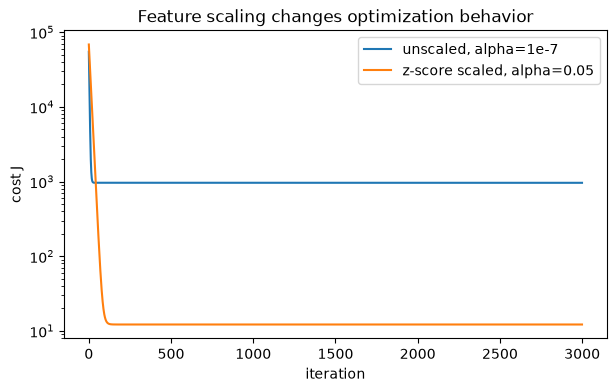

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(hist_unscaled, label="unscaled, alpha=1e-7")
plt.plot(hist_scaled, label="z-score scaled, alpha=0.05")
plt.xlabel("iteration")
plt.ylabel("cost J")
plt.title("Feature scaling changes optimization behavior")
plt.yscale("log")
plt.legend()
plt.show()



## 7. Learning rate and convergence

A useful diagnostic is the cost history:

$$
J^{(0)},J^{(1)},J^{(2)},\dots
$$

### Healthy behavior

Cost generally decreases and eventually flattens.

### Learning rate too small

Cost decreases, but unnecessarily slowly.

### Learning rate too large

The update may overshoot the minimum. Cost can oscillate or increase, and the optimization may diverge.

So doubling $\alpha$ does **not** imply twice-as-fast convergence.


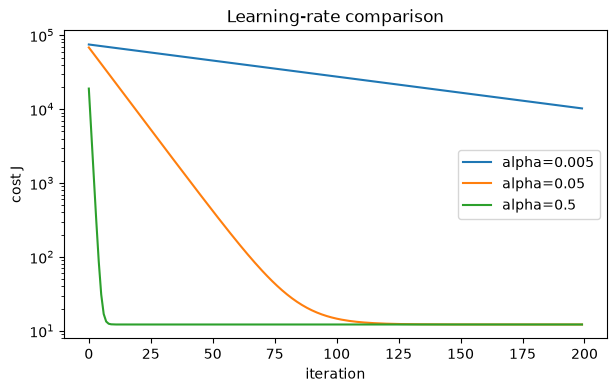

In [16]:
# Compare learning rates on the scaled dataset.
learning_rates = [0.005, 0.05, 0.5]
histories = {}

for alpha in learning_rates:
    _, _, hist = gradient_descent(
        X_scale_demo_z, y_scale_demo,
        alpha=alpha,
        num_iters=200
    )
    histories[alpha] = hist

plt.figure(figsize=(7, 4))
for alpha, hist in histories.items():
    plt.plot(hist, label=f"alpha={alpha}")

plt.xlabel("iteration")
plt.ylabel("cost J")
plt.title("Learning-rate comparison")
plt.yscale("log")
plt.legend()
plt.show()



## 8. Normal equation / least-squares solution

Linear regression with squared error has a closed-form least-squares solution.

If the bias is included as a column of ones in the design matrix,

$$
\tilde X
=
\begin{bmatrix}
1 & x_1^{(1)} & \cdots & x_n^{(1)}\\
1 & x_1^{(2)} & \cdots & x_n^{(2)}\\
\vdots & \vdots & & \vdots
\end{bmatrix},
$$

then the normal equations are

$$
\tilde X^T\tilde X\,\theta
=
\tilde X^T y.
$$

In the ideal full-rank case this is often written as

$$
\theta
=
(\tilde X^T\tilde X)^{-1}\tilde X^Ty.
$$

In numerical code, directly computing the inverse is usually unnecessary. A least-squares solver or pseudoinverse is preferable.

### Conceptual difference

**Gradient descent**

- iterative,
- needs a learning rate,
- scaling strongly affects convergence.

**Least-squares / normal-equation approach**

- directly solves the linear least-squares problem,
- no learning-rate tuning,
- practical numerical solvers handle singular / ill-conditioned cases more safely than explicit inversion.


In [17]:
X_aug = np.column_stack([np.ones(len(X)), X])

theta_lstsq, *_ = np.linalg.lstsq(X_aug, y, rcond=None)

b_lstsq = theta_lstsq[0]
w_lstsq = theta_lstsq[1:]

print("Least-squares b:", b_lstsq)
print("Least-squares w:", w_lstsq)
print("Training cost:", compute_cost(X, y, w_lstsq, b_lstsq))


Least-squares b: 188.40031941961456
Least-squares w: [  0.3866255  -56.13824955 -92.9672536   -3.73781915]
Training cost: 6.257072438234914e-21



## 9. Feature engineering

Feature engineering means constructing useful inputs from existing information.

Examples:

$$
\text{revenue}
=
\text{items sold}
\times
\text{price per item}
$$

or, for time-like variables,

$$
x_{\log}=\log(1+x).
$$

The important question is not “can I mathematically create this feature?” but:

> Does this transformation encode a relationship that is plausible and available at prediction time?

That last condition matters because a seemingly useful engineered feature can introduce leakage.


In [18]:
items_sold = np.array([10, 25, 7])
price_per_item = np.array([3.5, 2.0, 8.0])

engineered_revenue = items_sold * price_per_item
engineered_revenue


array([35., 50., 56.])


## 10. Polynomial regression

Polynomial regression creates nonlinear functions of the original inputs, for example:

$$
f(x)
=
w_1x+w_2x^2+w_3x^3+b.
$$

The prediction is nonlinear as a function of $x$, but it is still **linear in the parameters**

$$
(w_1,w_2,w_3,b).
$$

That is why ordinary linear-regression machinery can still fit polynomial features after we transform the input.

Polynomial features can improve fit, but adding higher powers increases model flexibility and can increase overfitting risk.


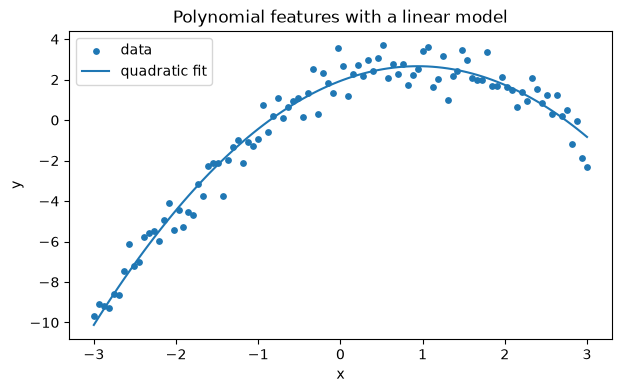

theta [b, w1, w2]: [ 1.93353704  1.54803676 -0.82348588]


In [19]:
rng = np.random.default_rng(7)

x_poly = np.linspace(-3, 3, 100)
y_poly = 2.0 + 1.5 * x_poly - 0.8 * x_poly**2 + rng.normal(0, 0.8, size=len(x_poly))

# Engineer [x, x^2] and solve with least squares.
X_poly = np.column_stack([x_poly, x_poly**2])
X_poly_aug = np.column_stack([np.ones(len(X_poly)), X_poly])

theta_poly, *_ = np.linalg.lstsq(X_poly_aug, y_poly, rcond=None)
y_poly_hat = X_poly_aug @ theta_poly

plt.figure(figsize=(7, 4))
plt.scatter(x_poly, y_poly, s=15, label="data")
plt.plot(x_poly, y_poly_hat, label="quadratic fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial features with a linear model")
plt.legend()
plt.show()

print("theta [b, w1, w2]:", theta_poly)



## 11. Scikit-learn equivalent

The same workflow can be expressed using scikit-learn components.

For gradient-descent-based regression, a clean pattern is:

1. fit the scaler on **training data only**,
2. transform training/validation/test data with that fitted scaler,
3. fit the model on the scaled training data.

Fitting a scaler on all data before the split would leak information from evaluation data into training.


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor

scaler = StandardScaler()
X_demo_scaled = scaler.fit_transform(X_scale_demo)

sgd = SGDRegressor(loss="squared_error",max_iter=5000,tol=1e-8,random_state=42)

sgd.fit(X_demo_scaled, y_scale_demo)

print("Intercept:", sgd.intercept_)
print("Weights:", sgd.coef_)


Intercept: [369.55362777]
Weights: [120.24054985  28.60983441]



## 12. Flagship connection

For the Month 2 flagship regression model, the current numeric feature set is:

- `lag_days`
- `history_seen`
- `history_correct`
- `history_accuracy`
- `lag_days_log`

The target is:

- `p_recall`

These features naturally live on different numerical scales. Therefore, for the gradient-descent-based multi-feature linear model, the initial decision is to **standardize the numeric features**.

### Scaling decision

- Fit scaling statistics on the training fold only.
- Reuse those statistics for validation/test transformations.
- Do not normalize the entire dataset before the split.
- Treat scaling as an optimization/preprocessing decision, not as a way of adding information.

The next Part should take the single-feature gradient-descent implementation from Month 1 and generalize it to the actual multi-feature flagship matrix.



## 13. My Own Exercise Implementation — Single-Feature Cost and Gradient

In the final linear-regression exercise, I wrote the core `compute_cost` and `compute_gradient` logic myself.

I keep only **my own implementation** here, not the surrounding course assignment, hints, tests, or solution material.

This is useful because it gives me a direct before/after comparison:

$$
\text{single-feature implementation I wrote by hand}
\quad\longrightarrow\quad
\text{multi-feature vectorized implementation}
$$

The underlying mathematics is the same.


In [21]:
# My original single-feature cost implementation, preserved from the exercise.

def compute_cost_single(x, y, w, b):
    m = x.shape[0]
    total_cost = 0

    for i in range(m):
        y_hat = w * x[i] + b
        cost = (y_hat - y[i]) ** 2
        total_cost += cost

    total_cost /= (2 * m)
    return total_cost


In [22]:
# My original single-feature gradient implementation, preserved from the exercise.

def compute_gradient_single(x, y, w, b):
    m = x.shape[0]

    dj_dw = 0
    dj_db = 0

    for i in range(m):
        temp_dj_dw = dj_dw + x[i] * (w * x[i] + b - y[i])
        temp_dj_db = dj_db + (w * x[i] + b - y[i])

        dj_dw = temp_dj_dw
        dj_db = temp_dj_db

    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db



### Verify my functions on a tiny single-feature dataset

Use a relation that is easy to reason about:

$$
y = 2x + 1.
$$

At the true parameters $w=2$, $b=1$, the cost and both gradients should be zero.


In [23]:
x_single = np.array([1.0, 2.0, 3.0, 4.0])
y_single = 2 * x_single + 1

cost_at_true = compute_cost_single(x_single, y_single, w=2.0, b=1.0)
dw_at_true, db_at_true = compute_gradient_single(
    x_single, y_single, w=2.0, b=1.0
)

print("Cost at true parameters:", cost_at_true)
print("dJ/dw at true parameters:", dw_at_true)
print("dJ/db at true parameters:", db_at_true)


Cost at true parameters: 0.0
dJ/dw at true parameters: 0.0
dJ/db at true parameters: 0.0



### From my loop implementation to matrix form

My single-feature gradient computes

$$
\frac{\partial J}{\partial w}
=
\frac{1}{m}
\sum_{i=1}^{m}
x^{(i)}
\left(
wx^{(i)}+b-y^{(i)}
\right).
$$

With multiple features, each example has a vector $\mathbf{x}^{(i)}$, so the same idea becomes

$$
\nabla_{\mathbf w}J
=
\frac{1}{m}
X^T
\left(
X\mathbf w+b-\mathbf y
\right).
$$

The key insight for me is:

> I did not learn a different gradient-descent algorithm for multiple regression.  
> I generalized the scalar accumulation I had already written into vector/matrix form.


In [24]:

X_single_matrix = x_single.reshape(-1, 1)
w_single_vector = np.array([0.7])
b_single = -0.2

single_cost = compute_cost_single(x_single, y_single,w=w_single_vector[0],b=b_single)
vectorized_cost = compute_cost(X_single_matrix, y_single,w=w_single_vector,b=b_single)
single_dw, single_db = compute_gradient_single(x_single, y_single,w=w_single_vector[0],b=b_single)
vectorized_dw, vectorized_db = compute_gradient(X_single_matrix, y_single,w=w_single_vector,b=b_single)

print("Cost equal:", np.isclose(single_cost, vectorized_cost))
print("dJ/dw equal:", np.isclose(single_dw, vectorized_dw[0]))
print("dJ/db equal:", np.isclose(single_db, vectorized_db))
print()
print("Single-feature cost:", single_cost)
print("Vectorized cost:", vectorized_cost)
print("Single-feature gradients:", (single_dw, single_db))
print("Vectorized gradients:", (vectorized_dw, vectorized_db))


Cost equal: True
dJ/dw equal: True
dJ/db equal: True

Single-feature cost: 10.957500000000001
Vectorized cost: 10.957500000000001
Single-feature gradients: (np.float64(-12.75), np.float64(-4.45))
Vectorized gradients: (array([-12.75]), np.float64(-4.45))



### What this exercise proves

The vectorized multi-feature code is not a black-box replacement for what I wrote by hand.

It is the same computation expressed at a higher level:

```text
my loop over training examples
        ↓
residuals for all examples
        ↓
matrix/vector operations
        ↓
same cost and same gradient
```

That is the bridge I want to retain going into Part 2, where the implementation is applied to the real flagship features.



## 14. Recall checkpoint

Without looking above, I should be able to answer:

1. What are the shapes of $X$, $\mathbf w$, and $\mathbf y$?
2. Why is $\mathbf w^T\mathbf x+b$ the natural multi-feature extension of $wx+b$?
3. What does vectorization change, and what does it **not** change mathematically?
4. Why is $\nabla_{\mathbf w}J$ a vector?
5. Why can very different feature scales slow gradient descent?
6. What is the difference between mean normalization and z-score normalization?
7. What does an increasing cost curve suggest about $\alpha$?
8. Why does doubling $\alpha$ not guarantee twice-as-fast convergence?
9. How does the normal-equation / least-squares approach differ from gradient descent?
10. Why can polynomial regression produce a curved prediction while still being linear regression in the parameters?
11. What makes an engineered feature useful rather than merely available?
12. Why must a scaler be fit only on training data?
